# Wildfire Risk with dILP


In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
sys.path.append('LoH/experiments/DILP')

from src.wildfire import (
    REGIME_FULL_KNOWLEDGE,
    REGIME_SELECT_RELIABLE,
    REGIME_SELECT_ONE_PER_SET,
    REGIME_PARTIAL_FUEL_KNOWN,
)
from src.wildfire.runner import run_regime

plt.rcParams.update({
    'figure.dpi': 300,
    'font.family': 'serif',
    'font.size': 15,
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})


DATASET_DIR = "LoH/experiments/data/wildfire_risk"
RESULTS_DIR = "LoH/experiments/results/wildfire_risk_dilp_new"
RESULTS_LOH_DIR = "LoH/experiments/results/wildfire_risk"
IMG_DIR = os.path.join(DATASET_DIR, "images")
CSV_PATH = os.path.join(DATASET_DIR, "labels.csv")

LABELS = {
    REGIME_FULL_KNOWLEDGE: 'Full Knowledge',
    REGIME_SELECT_RELIABLE: 'Selecting Reliable Rules',
    REGIME_SELECT_ONE_PER_SET: 'Selecting One Rule per Set',
    REGIME_PARTIAL_FUEL_KNOWN: 'Partial Knowledge Base, Fuel Known',
}

REGIMES = LABELS.keys()

In [ ]:
if not os.path.exists(IMG_DIR) or not os.path.exists(CSV_PATH):
    sys.path.append('LoH/experiments/')
    from generate_data import prepare_wildfire_dataset
    prepare_wildfire_dataset(dataset_dir=DATASET_DIR, non_visual_seed=61, split_seed=30, train_ratio=0.75, force_regenerate=False)
else:
    print("Images and CSV already exist. Skipping generation.")

Images and CSV already exist. Skipping generation.


In [3]:
COMMON = dict(
    dataset_dir=DATASET_DIR,
    results_dir=RESULTS_DIR,
    epochs=25,
    repetitions=20,
    batch_size=256,
    lr_rules=0.08,
    lr_cnn=8e-4,
    dropout=0.15,
    train_ratio=0.75,
    split_seed=30,
    non_visual_seed=61,
    use_persisted_split=True,
    use_minibatch=True,
    print_examples_per_epoch=0,
    print_visual_head_metrics=True,
)


In [4]:
from src.wildfire.constants import VISUAL_VARIABLES, NON_VISUAL_VARIABLES
from src.wildfire.data import load_wildfire_table, train_test_split_indices

def print_wildfire_dataset_stats(visual, non_visual, labels, train_idx, val_idx, visual_names, non_visual_names):
    labels = labels.astype(np.float32).reshape(-1)
    visual = visual.astype(np.float32)
    non_visual = non_visual.astype(np.float32)

    print("Wildfire dataset statistics")
    print(f"- samples: {len(labels)}")
    print(f"- train/val: {len(train_idx)}/{len(val_idx)}")
    print(f"- positive labels: {int(labels.sum())}/{len(labels)} ({labels.mean():.3f})")
    print(f"- train positive ratio: {labels[train_idx].mean():.3f}")
    print(f"- val positive ratio: {labels[val_idx].mean():.3f}")
    print("- visual feature prevalence:")
    for i, name in enumerate(visual_names):
        print(f"  {name}: {visual[:, i].mean():.3f}")
    print("- non-visual feature prevalence:")
    for i, name in enumerate(non_visual_names):
        print(f"  {name}: {non_visual[:, i].mean():.3f}")

table = load_wildfire_table(
    dataset_dir=COMMON["dataset_dir"],
    non_visual_seed=COMMON.get("non_visual_seed", 42),
)
if table["train_indices"] is not None and table["val_indices"] is not None:
    train_idx, val_idx = table["train_indices"], table["val_indices"]
else:
    train_idx, val_idx = train_test_split_indices(
        len(table["labels"]),
        train_ratio=COMMON["train_ratio"],
        seed=COMMON["split_seed"],
    )

print_wildfire_dataset_stats(
    table["visual_features"],
    table["non_visual_features"],
    table["labels"],
    train_idx,
    val_idx,
    VISUAL_VARIABLES,
    NON_VISUAL_VARIABLES,
)


Wildfire dataset statistics
- samples: 2048
- train/val: 1536/512
- positive labels: 689/2048 (0.336)
- train positive ratio: 0.335
- val positive ratio: 0.340
- visual feature prevalence:
  dense_forest: 0.506
  dry_vegetation: 0.414
- non-visual feature prevalence:
  low_humidity: 0.500
  strong_wind: 0.495
  rained_recently: 0.483
  high_temperature: 0.478
  minimal_human_activity: 0.489
  lightnings_frequent: 0.493
  power_lines_nearby: 0.489


In [5]:
results = {}
for regime in REGIMES:
    print('Running', regime)
    results[regime] = run_regime(regime=regime, **COMMON)
    print('-'*80)


Running full_knowledge


2026-02-18 01:23:03.281141: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-02-18 01:23:03.281173: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-02-18 01:23:03.281179: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-02-18 01:23:03.281308: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-18 01:23:03.281323: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


regime=full_knowledge rep=1 epoch=1 loss=0.3584 train_f1=0.7006 val_f1=0.7159
  visual_heads: 
  ACCURACY: DENSE FOREST val = 0.533  DRY VEGETATION val = 1.000 
  MEAN: DENSE FOREST val = 0.487 DRY VEGETATION val = 0.460
regime=full_knowledge rep=1 epoch=2 loss=0.3095 train_f1=0.8110 val_f1=0.8227
  visual_heads: 
  ACCURACY: DENSE FOREST val = 0.662  DRY VEGETATION val = 1.000 
  MEAN: DENSE FOREST val = 0.556 DRY VEGETATION val = 0.507
regime=full_knowledge rep=1 epoch=3 loss=0.2374 train_f1=0.9343 val_f1=0.9428
  visual_heads: 
  ACCURACY: DENSE FOREST val = 0.992  DRY VEGETATION val = 1.000 
  MEAN: DENSE FOREST val = 0.535 DRY VEGETATION val = 0.455
regime=full_knowledge rep=1 epoch=4 loss=0.1082 train_f1=0.9941 val_f1=0.9825
  visual_heads: 
  ACCURACY: DENSE FOREST val = 0.977  DRY VEGETATION val = 1.000 
  MEAN: DENSE FOREST val = 0.533 DRY VEGETATION val = 0.440
regime=full_knowledge rep=1 epoch=5 loss=0.0180 train_f1=1.0000 val_f1=1.0000
  visual_heads: 
  ACCURACY: DENSE FOR

In [6]:
from collections import Counter
import re
from src.wildfire.constants import CANDIDATE_RULE_GROUPS, FUEL_KNOWN_INDEX

# Build a stable candidate -> formula mapping used to decode learned dILP choices.
_CANDIDATE_TO_FORMULA = {}
_CANDIDATE_ORDER = {}
_order = 0
for _group_name in ('fuel', 'dry', 'trigger'):
    for _idx, _formula in enumerate(CANDIDATE_RULE_GROUPS[_group_name]):
        _cand_name = f'cand_{_group_name}_{_idx}'
        _CANDIDATE_TO_FORMULA[_cand_name] = _formula
        _CANDIDATE_ORDER[_cand_name] = _order
        _order += 1

_CAND_RE = re.compile(r'^cand_(fuel|dry|trigger)_(\d+)$')


def _extract_cand_from_clause(clause):
    if not isinstance(clause, str) or '<-' not in clause:
        return None
    body = clause.split('<-', 1)[1]
    first_atom = body.split(',', 1)[0].strip()
    pred = first_atom.split('(', 1)[0]
    if _CAND_RE.match(pred):
        return pred
    return None


def _formula_from_selected_run(regime, selected_run):
    selected = []

    if regime in (REGIME_FULL_KNOWLEDGE, REGIME_SELECT_ONE_PER_SET):
        for head in ('fuel_sel(X_0)', 'dry_sel(X_0)', 'trigger_sel(X_0)'):
            if head in selected_run:
                cand = _extract_cand_from_clause(selected_run[head].get('tau1'))
                if cand is not None:
                    selected.append(cand)

    elif regime == REGIME_SELECT_RELIABLE:
        for head, choice in selected_run.items():
            if head.startswith('gate_'):
                cand = _extract_cand_from_clause(choice.get('tau1'))
                if cand is not None:
                    selected.append(cand)

    elif regime == REGIME_PARTIAL_FUEL_KNOWN:
        fuel_cand = None
        if 'fuel_sel(X_0)' in selected_run:
            fuel_cand = _extract_cand_from_clause(selected_run['fuel_sel(X_0)'].get('tau1'))
        if fuel_cand is None:
            fuel_cand = f'cand_fuel_{FUEL_KNOWN_INDEX}'
        selected.append(fuel_cand)

        for head, choice in selected_run.items():
            if head.startswith('gate_'):
                cand = _extract_cand_from_clause(choice.get('tau1'))
                if cand is not None:
                    selected.append(cand)

    selected = sorted(set(selected), key=lambda x: _CANDIDATE_ORDER.get(x, 10**9))
    terms = [f"({_CANDIDATE_TO_FORMULA[cand]})" for cand in selected if cand in _CANDIDATE_TO_FORMULA]
    return ' & '.join(terms) if terms else 'TRUE'


def summarize_learned_formulas(results_by_regime):
    summary = {}
    for regime in REGIMES:
        runs = results_by_regime[regime]['selected_rules']
        formulas = [_formula_from_selected_run(regime, run) for run in runs]
        summary[regime] = formulas

        print(f"\n=== {LABELS[regime]} ({regime}) ===")
        for rep_idx, formula in enumerate(formulas, start=1):
            print(f"rep {rep_idx:02d}: {formula}")

        print('Unique formulas:')
        counts = Counter(formulas)
        for formula, cnt in counts.most_common():
            print(f"  {cnt}/{len(formulas)} reps -> {formula}")

    return summary


learned_formulas = summarize_learned_formulas(results)




=== Full Knowledge (full_knowledge) ===
rep 01: (dense_forest | (dry_vegetation & strong_wind)) & (low_humidity | (high_temperature & ~rained_recently)) & (lightnings_frequent | ~minimal_human_activity | power_lines_nearby)
rep 02: (dense_forest | (dry_vegetation & strong_wind)) & (low_humidity | (high_temperature & ~rained_recently)) & (lightnings_frequent | ~minimal_human_activity | power_lines_nearby)
rep 03: (dense_forest | (dry_vegetation & strong_wind)) & (low_humidity | (high_temperature & ~rained_recently)) & (lightnings_frequent | ~minimal_human_activity | power_lines_nearby)
rep 04: (dense_forest | (dry_vegetation & strong_wind)) & (low_humidity | (high_temperature & ~rained_recently)) & (lightnings_frequent | ~minimal_human_activity | power_lines_nearby)
rep 05: (dense_forest | (dry_vegetation & strong_wind)) & (low_humidity | (high_temperature & ~rained_recently)) & (lightnings_frequent | ~minimal_human_activity | power_lines_nearby)
rep 06: (dense_forest | (dry_vegetation

In [7]:
# SAVE/VERIFY DILP RESULTS
save_dir = COMMON.get('results_dir', RESULTS_DIR)
os.makedirs(save_dir, exist_ok=True)
index_path = os.path.join(save_dir, 'notebook_results_index.json')

if os.path.exists(index_path):
    with open(index_path, 'r') as f:
        index = json.load(f)
else:
    index = {}

saved_now = 0
verified_existing = 0

for regime in REGIMES:
    run = results[regime]
    run_id = run['run_id']
    train_path = os.path.join(save_dir, f'f1_train_hist_{run_id}.npy')
    val_path = os.path.join(save_dir, f'f1_val_hist_{run_id}.npy')
    rules_path = os.path.join(save_dir, f'selected_rules_{run_id}.json')

    if not os.path.exists(train_path):
        np.save(train_path, run['f1_train_hist'])
        saved_now += 1
    else:
        verified_existing += 1

    if not os.path.exists(val_path):
        np.save(val_path, run['f1_val_hist'])
        saved_now += 1
    else:
        verified_existing += 1

    if not os.path.exists(rules_path):
        with open(rules_path, 'w') as f:
            json.dump(run['selected_rules'], f, indent=2)
        saved_now += 1
    else:
        verified_existing += 1

    index[regime] = {
        'run_id': run_id,
        'train_path': train_path,
        'val_path': val_path,
        'rules_path': rules_path,
    }

with open(index_path, 'w') as f:
    json.dump(index, f, indent=2)

print(f'Saved new files: {saved_now}, verified existing files: {verified_existing}')
print('Index file:', index_path)
index


Saved new files: 0, verified existing files: 12
Index file: GodelNNs/experiments/results/wildfire_risk_dilp_new/notebook_results_index.json


{'full_knowledge': {'run_id': 'full_knowledge_599d1bc9',
  'train_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/f1_train_hist_full_knowledge_599d1bc9.npy',
  'val_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/f1_val_hist_full_knowledge_599d1bc9.npy',
  'rules_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/selected_rules_full_knowledge_599d1bc9.json'},
 'select_reliable_rules': {'run_id': 'select_reliable_rules_ec77aaf1',
  'train_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/f1_train_hist_select_reliable_rules_ec77aaf1.npy',
  'val_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/f1_val_hist_select_reliable_rules_ec77aaf1.npy',
  'rules_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/selected_rules_select_reliable_rules_ec77aaf1.json'},
 'select_one_rule_per_set': {'run_id': 'select_one_rule_per_set_946681a2',
  'train_path': 'GodelNNs/experiments/results/wildfire_risk_dilp_new/f1_train_hist_select_one_rule_p

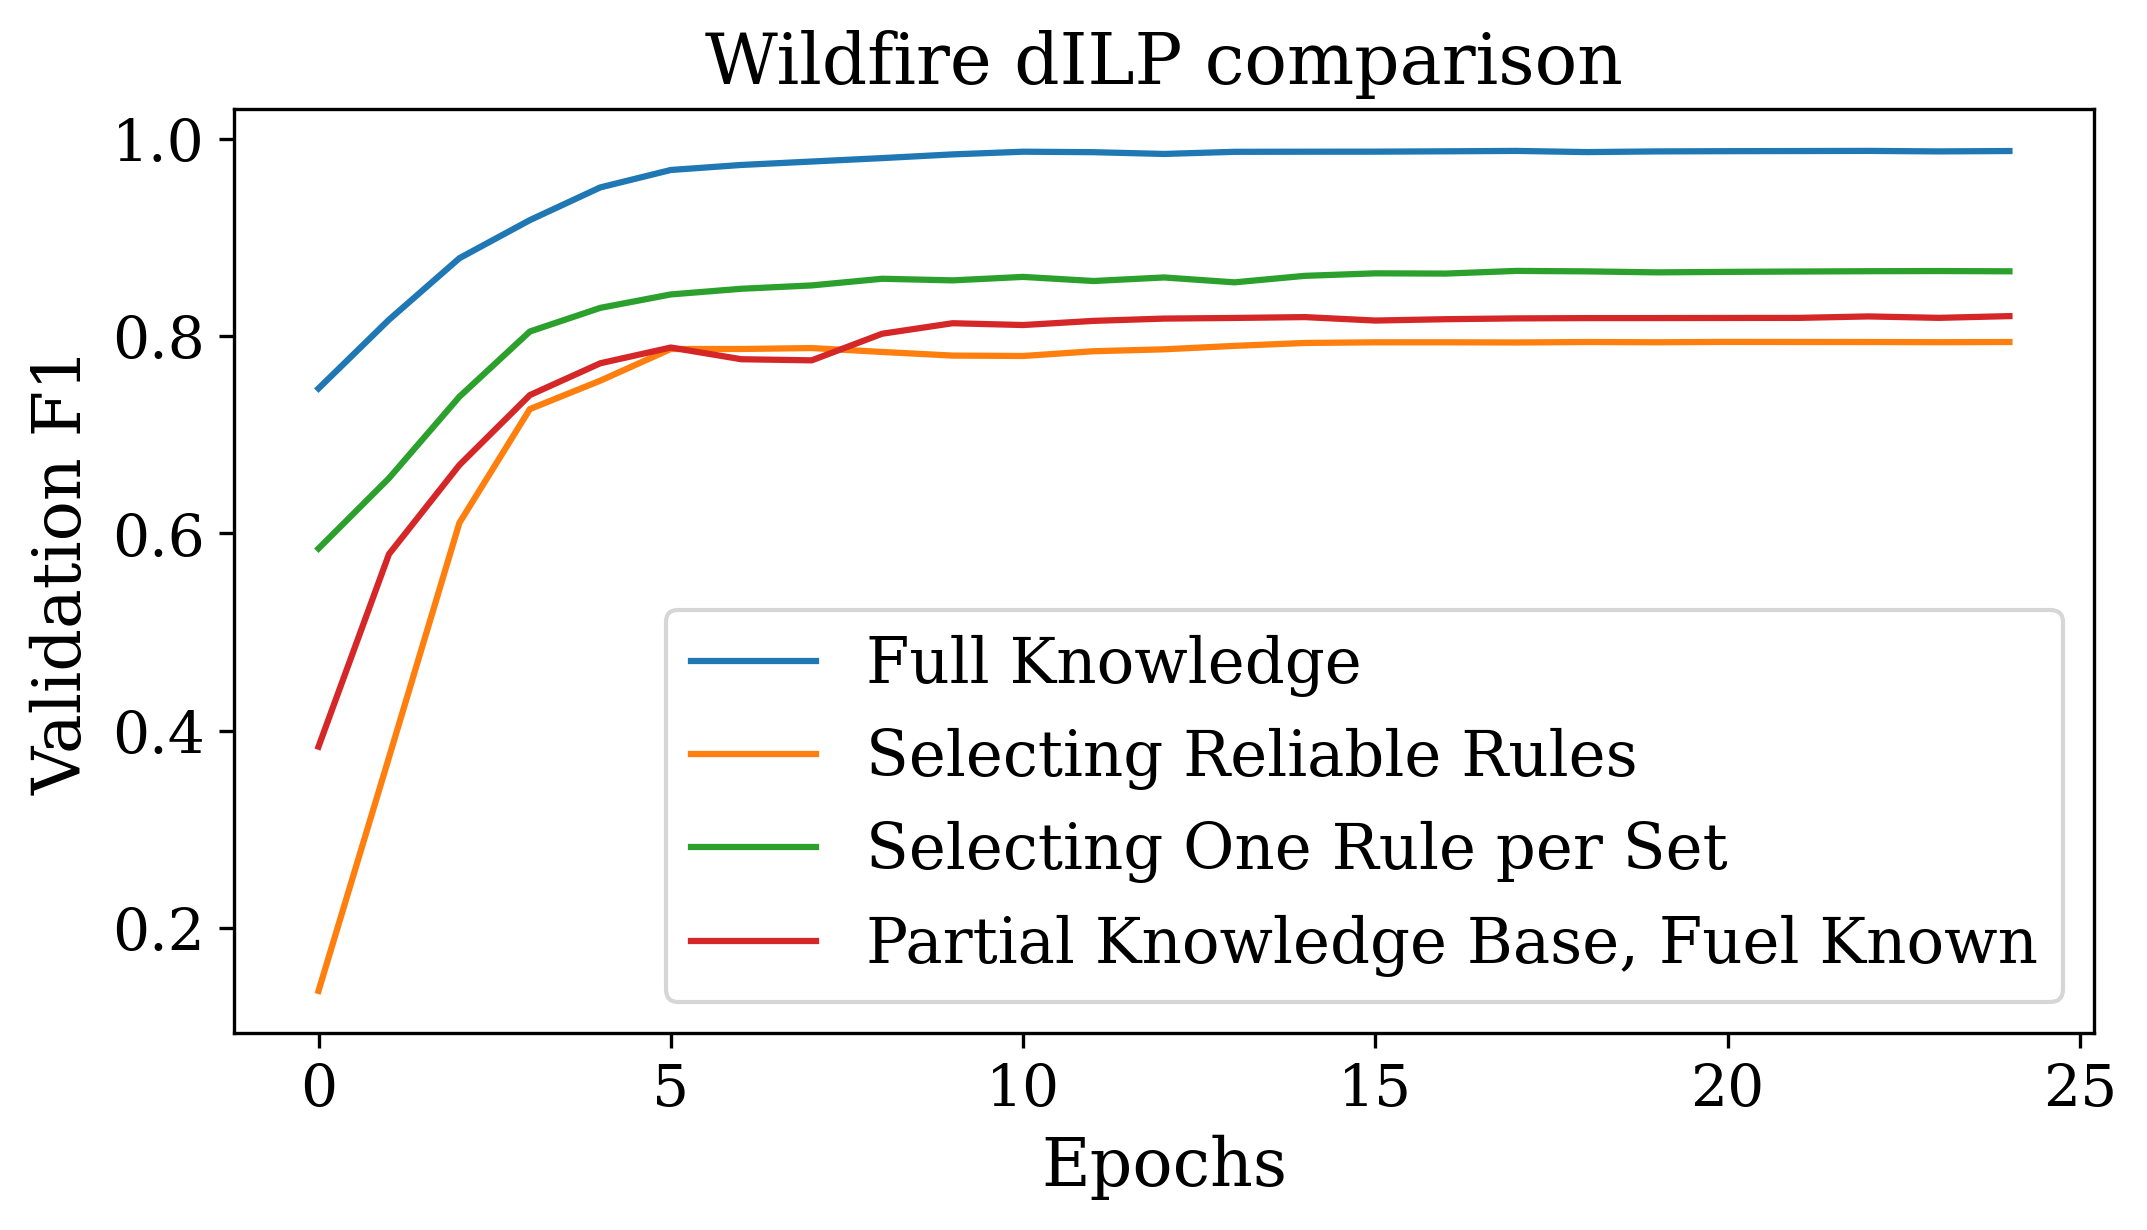

In [8]:
plt.figure(figsize=(8,4))
for regime in REGIMES:
    mean_val = np.mean(results[regime]['f1_val_hist'], axis=0)
    plt.plot(mean_val, label=LABELS[regime])
plt.xlabel('Epochs')
plt.ylabel('Validation F1')
plt.title('Wildfire dILP comparison')
plt.legend()
plt.show()


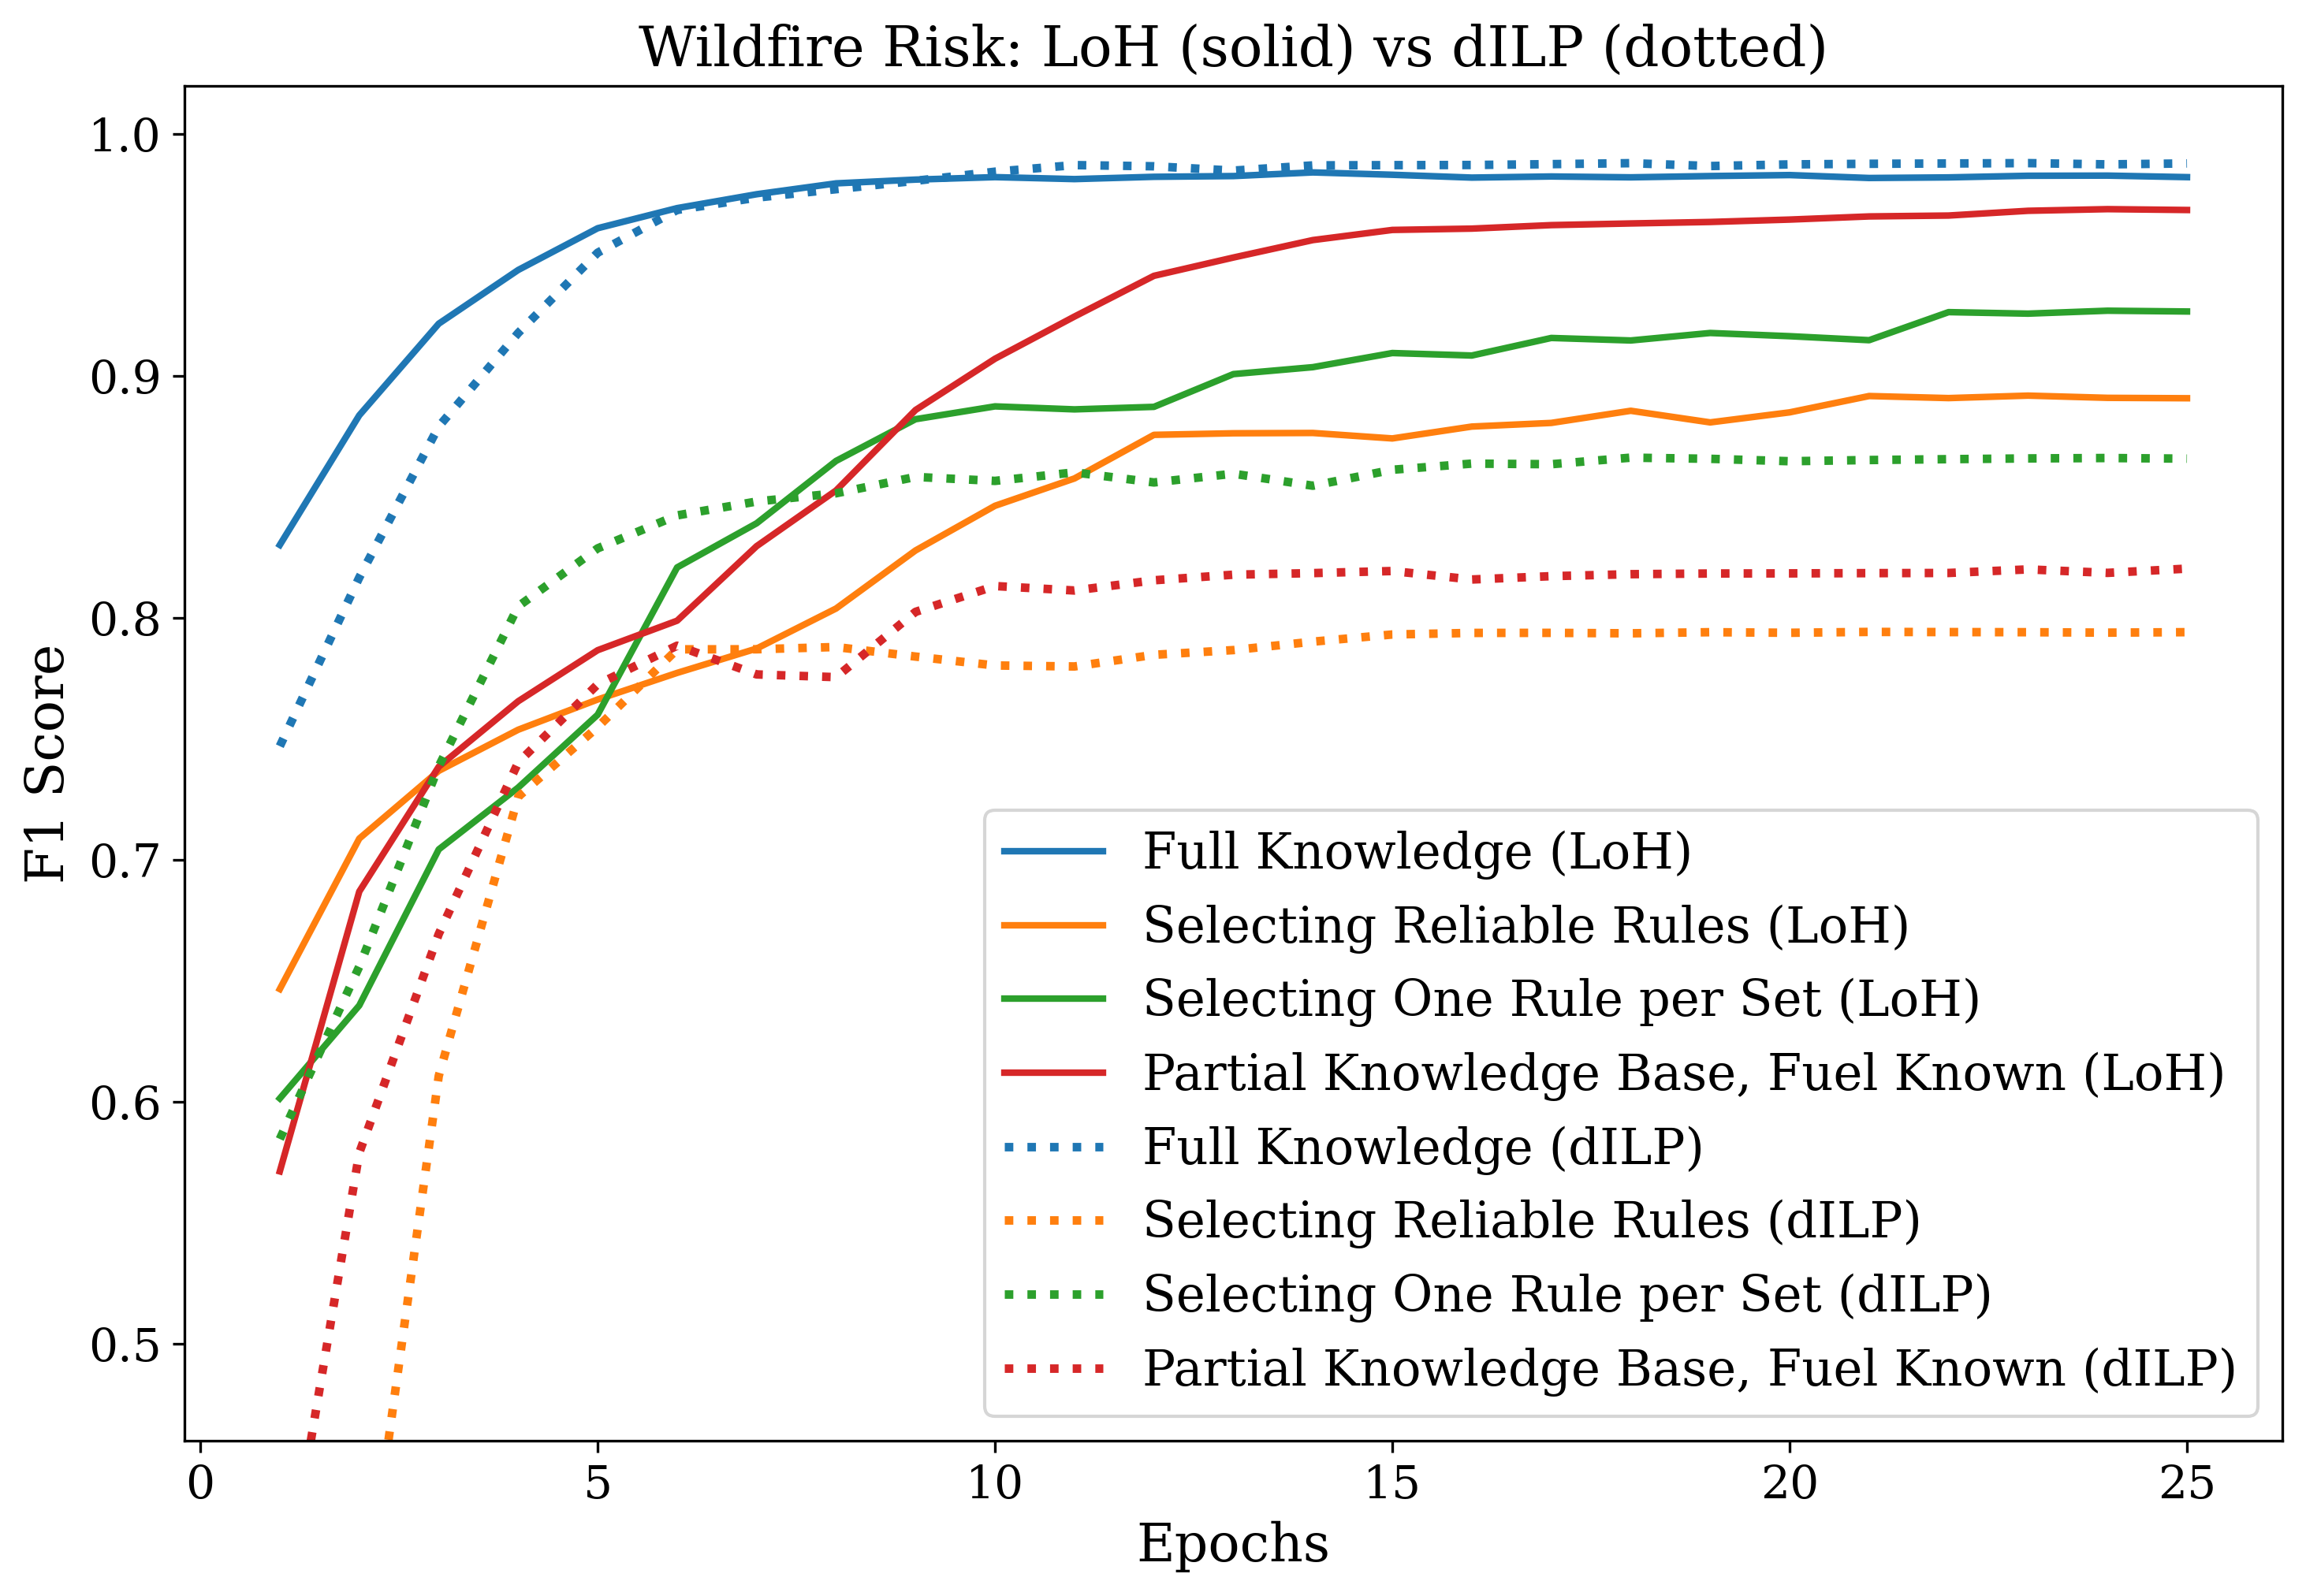

Loaded LoH files:
- Full Knowledge: GodelNNs/experiments/results/wildfire_risk/f1_val_hist_ground_truth_given.npy
- Selecting Reliable Rules: GodelNNs/experiments/results/wildfire_risk/f1_val_hist_select_rules_among_all.npy
- Selecting One Rule per Set: GodelNNs/experiments/results/wildfire_risk/f1_val_hist_select_one_per_list.npy
- Partial Knowledge Base, Fuel Known: GodelNNs/experiments/results/wildfire_risk/f1_val_hist_fuel_given_select_rules_among_others.npy


In [9]:
# COMBINED LOH + DILP PLOT

index_path = os.path.join(RESULTS_DIR, 'notebook_results_index.json')

# Load dILP curves from persisted notebook index (saved in previous cell).
with open(index_path, 'r') as f:
    dilp_index = json.load(f)

dilp_mean = {}
for regime in REGIMES:
    val_hist = np.load(dilp_index[regime]['val_path'])
    dilp_mean[regime] = np.mean(val_hist, axis=0)

# LoH files for the four comparable regimes.
loh_name_candidates = {
    REGIME_FULL_KNOWLEDGE: ['f1_val_hist_ground_truth_given.npy'],
    REGIME_SELECT_RELIABLE: ['f1_val_hist_select_rules_among_all.npy'],
    REGIME_SELECT_ONE_PER_SET: ['f1_val_hist_select_one_per_list.npy'],
    REGIME_PARTIAL_FUEL_KNOWN: ['f1_val_hist_fuel_given_select_rules_among_others.npy'],
}

loh_bases = [Path(RESULTS_LOH_DIR)]

def _find_loh_file(candidates):
    for base in loh_bases:
        for name in candidates:
            p = base / name
            if p.exists():
                return p
    return None

loh_paths = {regime: _find_loh_file(names) for regime, names in loh_name_candidates.items()}
loh_mean = {}
for regime, path in loh_paths.items():
    if path is None:
        continue
    arr = np.load(path)
    loh_mean[regime] = np.mean(arr, axis=0) if arr.ndim > 1 else arr

colors = {regime: f'C{i}' for i, regime in enumerate(REGIMES)}

plt.figure(figsize=(10, 7))

max_epochs = 25

for regime in REGIMES:
    c = colors[regime]
    if regime in loh_mean:
        x = 1 + np.arange(max_epochs)
        plt.plot(x, loh_mean[regime][:max_epochs], color=c, linestyle='-', linewidth=2.0, label=f"{LABELS[regime]} (LoH)")

for regime in REGIMES:
    c = colors[regime]
    x = 1 + np.arange(max_epochs)
    plt.plot(x, dilp_mean[regime][:max_epochs], color=c, linestyle=':', linewidth=2.6, label=f"{LABELS[regime]} (dILP)")



plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Wildfire Risk: LoH (solid) vs dILP (dotted)')
plt.legend() #ncol=2)
plt.ylim(0.46, 1.02)
#plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

missing = [LABELS[r] for r in REGIMES if r not in loh_mean]
if missing:
    print('Missing LoH files for:', ', '.join(missing))
else:
    print('Loaded LoH files:')
    for regime in REGIMES:
        print(f"- {LABELS[regime]}: {loh_paths[regime]}")
